# 07_NarrativeRisk_LLM_PostFormation

Same tercile spread as quantlet 01 but inserts a one-month skip between portfolio formation and the first holding-period return. Tests sensitivity of the headline alpha to short-horizon market microstructure. Indicative not inferential.

**Axis exercised:** Skip-month formation lag

Headline numbers reported below are **indicative not inferential** at N=30 firms x 10 fiscal years and are **not intended as evidence**.


## Why a skip-month quantlet?

Quantlet 01 forms portfolios at the start of each calendar year and holds them for all 12 months of that year, including January.
That construction implicitly assumes the signal (composite severity from the prior fiscal year's 10-K) is already public information at the moment of portfolio formation, and that the first month of the holding window is fully tradeable on that signal.

Two structural concerns motivate testing a skip-month variant.

First, real 10-K filings are submitted to EDGAR within 60 to 90 days of the fiscal year end (the SEC's accelerated-filer deadline is 60 days for large filers).
A firm with a December 31 fiscal year-end typically files its 10-K in late February or early March of the following year.
A portfolio formed on January 1 with a signal labelled `signal_year = y - 1` is therefore using information that may not yet be public; the no-look-ahead invariant is technically violated for the first 60 calendar days of the holding window.

Second, the academic literature on cross-sectional return predictors has documented short-horizon market microstructure effects: post-earnings-announcement drift, January-effect concentration, mean-reversion at the one-month horizon, and bid-ask bounce in the immediate weeks after a portfolio formation date.
A spread that earns most of its alpha in the first month after formation is harder to interpret as evidence for the underlying signal; a spread that earns alpha across the remaining 11 months is more robust.

This quantlet addresses both concerns with the same fix.
It re-runs quantlet 01's tercile sort and FF5+UMD regression with one change: the holding window for portfolio_year `y` starts in February `y` instead of January `y`, dropping the first calendar month of returns.
The key point is not that February is "the right month" to start; it is that the alpha estimate should be relatively insensitive to dropping the first month if the underlying signal is real.


## Methodology

```
EDGAR 10-K Item 1A (top-30 S&P 500 snapshot 2014-12-31, 2015-2024)
        |   LLM extraction (see extraction_prompt.md)
        v
corpus.ndjson.gz (~3000 records: 30 firms x 10 years x 10 themes, severity 0-5)
        |   compute_theme_exposures (mean across 10 themes)
        v
composite_severity per (firm, signal_year)
        |   form_terciles_with_lag (signal_year y-1 -> portfolio_year y)
        v
tercile (or decile) assignments + monthly returns
        |   axis-specific transform: Skip-month formation lag
        v
postformation_spread_summary.csv + figure(s)
```


## Cross-sectional sort and the lag invariant

The panel design is a year-by-year cross-sectional sort.
Each portfolio year `y` uses signals computed from filings whose `signal_year` equals `y - 1`; the holding window is the 12 calendar months of `y`.
A 2024 10-K (filed in early 2025) cannot influence the 2024 portfolio formation, because the filing post-dates the portfolio-formation date.

This rule is the panel's no-look-ahead invariant.
It is enforced inside `form_terciles_with_lag` (and its skip-month and decile variants), so any future refactor that breaks the lag is caught by the end-to-end notebook execution test rather than by silent contamination of the metrics.

Two consequences of this design are worth noting.
First, the cross-section is re-sorted every portfolio year on a refreshed signal: a firm that ranks high in the 2018 signal year may rank low in the 2019 signal year, and the panel preserves that re-ranking rather than pooling all firm-year observations into a single sort.
Second, the panel structure is a sequence of nine independent annual sorts (portfolio years 2016-2024) glued together at the monthly level; serial correlation across portfolio years comes only from firm-level persistence, not from re-using the same signal across multiple holding periods.

Pooling signals across years (e.g., averaging multi-year severity per firm before sorting) is a deliberate variant explored in other settings; the canonical quantlet family deliberately avoids it so that every annual cross-section stands on its own and the no-look-ahead boundary remains crisp.


## What the skip-month construction does mechanically

The skip is implemented inside `form_terciles_with_skip_lag`, a near-clone of quantlet 01's `form_terciles_with_lag` that takes a `skip_months` integer parameter (default 1).
For each portfolio year `y`, the function:

- Looks up signal year `y - 1`'s severities (unchanged).
- Sorts firms into terciles via `pd.qcut` on `composite_severity` (unchanged).
- Filters the year's monthly returns to drop the first `skip_months` calendar months from January `y` (new step).

A `skip_months = 1` setting drops January `y`; `skip_months = 0` reduces to the canonical quantlet 01 construction; larger values (3, 6) would test progressively conservative implementation lags.
The default of 1 is calibrated to address the SEC filing-deadline concern (a firm filing in late February is already public by the start of February for tradability purposes). More conservative skips of 3 or 6 months would push the holding window past the filing-season cluster but are not investigated here.

Two consequences of this construction.

First, the n_obs count drops from 108 (9 portfolio years times 12 months) to 99 (9 portfolio years times 11 months) because each year loses its January observation.
The HC1 t-statistic on the alpha is therefore re-estimated on a slightly smaller sample; the small-sample distribution warning still applies.

Second, the spread's market beta is essentially unchanged but the residual volatility may differ subtly because January returns are systematically different from other months in many cross-sections (the January effect, tax-loss harvesting reversals, fund-rebalancing flows).
Reading the alpha point-estimate side by side with quantlet 01's tells you whether the canonical alpha was carried by January returns or by the rest of the year.


In [1]:
from __future__ import annotations

import csv
import gzip
import json
import re
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

HERE = Path.cwd()


In [2]:
PROVENANCE_PATH = HERE / "provenance.json"   # audit trail (not read at runtime; ships for transparency)
SUMMARY_OUT = HERE / "postformation_spread_summary.csv"
FIGURE_OUT = HERE / "postformation_spread.pdf"


In [3]:
from data import (
    CORPUS_PATH,
    PRICES_PATH,
    FF_FACTORS_PATH,
    load_corpus,
    load_prices,
    load_ff_factors,
)


In [4]:
def compute_theme_exposures(corpus_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-firm-year severity into a single composite exposure.

    Composite signal = mean severity across the 10 themes (range 0..5).
    Returns: DataFrame with cols [firm, signal_year, composite_severity].
    """
    agg = (
        corpus_df.groupby(["firm", "year"])["severity_0_5"]
        .mean()
        .reset_index()
        .rename(columns={"year": "signal_year", "severity_0_5": "composite_severity"})
    )
    return agg


In [5]:
def form_terciles_with_skip_lag(
    signals: pd.DataFrame,
    returns: pd.DataFrame,
    skip_months: int = 1,
) -> pd.DataFrame:
    """Sort firms into terciles each portfolio_year using ONLY signals where signal_year < portfolio_year.

    Identical to quantlet 01's form_terciles_with_lag except that the first
    `skip_months` calendar months of each holding year are dropped before
    adding the rows to the panel.

    For each portfolio_year y in 2020..2024 (we need at least one prior signal year):
      - Use signals from signal_year = y - 1
      - Assign firms to tercile labels {1: low, 2: mid, 3: high} based on composite_severity
      - Apply tercile assignment to that firm's monthly returns over portfolio_year y,
        EXCLUDING the first `skip_months` months of y.

    Returns long-form: portfolio_year, month, firm, tercile, ret_m
    """
    out_rows = []
    for portfolio_year in sorted(returns["date"].dt.year.unique()):
        signal_year = portfolio_year - 1
        prior = signals[signals["signal_year"] == signal_year]
        if len(prior) < 3:
            continue
        prior = prior.copy()
        prior["tercile"] = pd.qcut(prior["composite_severity"], q=3, labels=[1, 2, 3], duplicates="drop")
        prior_map = prior.set_index("firm")["tercile"].to_dict()
        year_returns = returns[returns["date"].dt.year == portfolio_year].copy()
        # Drop the first skip_months calendar months (e.g. January when skip_months=1)
        if skip_months > 0:
            min_month = year_returns["date"].dt.month.min()
            cutoff_month = min_month + skip_months - 1
            year_returns = year_returns[year_returns["date"].dt.month > cutoff_month]
        year_returns["tercile"] = year_returns["firm"].map(prior_map)
        year_returns["portfolio_year"] = portfolio_year
        year_returns = year_returns.dropna(subset=["tercile"])
        out_rows.append(
            year_returns[["portfolio_year", "date", "firm", "tercile", "ret_m"]].rename(
                columns={"date": "month"}
            )
        )
    if not out_rows:
        return pd.DataFrame(columns=["portfolio_year", "month", "firm", "tercile", "ret_m"])
    return pd.concat(out_rows, ignore_index=True)


def tercile_spread_test(panel: pd.DataFrame, ff: pd.DataFrame) -> Dict[str, float]:
    """Equal-weight tercile portfolios, compute long-short (T3 - T1) monthly series.

    Returns dict with: tercile_spread_pct_yr, tercile_spread_t_stat_indicative,
                       sharpe_indicative, max_drawdown, n_observations,
                       alpha_pct_yr, alpha_t_stat_indicative.
    Alpha is FF5+UMD risk-adjusted intercept from OLS with HC1 robust SE.
    All metrics are INDICATIVE only (N=30 firms, 9 portfolio years -> ~99 obs with 1-month skip).
    """
    panel = panel.copy()
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")
    bin_returns = panel.groupby(["month_period", "tercile"])["ret_m"].mean().unstack("tercile")
    spread = (bin_returns[3] - bin_returns[1]).dropna()

    n = int(len(spread))
    mean_m = float(spread.mean())
    std_m = float(spread.std(ddof=1))
    annualized_pct = mean_m * 12 * 100
    t_stat = mean_m / (std_m / np.sqrt(n)) if (std_m > 0 and n > 1) else float("nan")
    sharpe = (mean_m / std_m) * np.sqrt(12) if std_m > 0 else float("nan")

    cum = (1 + spread).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = float(drawdown.min()) if len(drawdown) > 0 else float("nan")

    # FF5+UMD risk-adjusted alpha (HC1 robust SE).
    spread_df = spread.rename("spread").reset_index()
    merged = spread_df.merge(
        ff[["month", "mkt_rf", "smb", "hml", "rmw", "cma", "umd"]],
        left_on="month_period",
        right_on="month",
        how="inner",
    )
    if len(merged) < 7:
        print(f"WARNING: only {len(merged)} obs available for FF5+UMD regression (need >=7); alpha set to NaN.")
        alpha_pct_yr = float("nan")
        alpha_t_stat = float("nan")
    else:
        X = sm.add_constant(merged[["mkt_rf", "smb", "hml", "rmw", "cma", "umd"]])
        y = merged["spread"]
        model = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
        alpha_monthly = float(model.params["const"])
        alpha_t_stat = float(model.tvalues["const"])
        alpha_pct_yr = alpha_monthly * 12 * 100

    return {
        "tercile_spread_pct_yr": annualized_pct,
        "tercile_spread_t_stat_indicative": float(t_stat),
        "sharpe_indicative": float(sharpe),
        "max_drawdown": max_dd,
        "n_observations": n,
        "alpha_pct_yr": alpha_pct_yr,
        "alpha_t_stat_indicative": alpha_t_stat,
    }


def plot_postformation_spread(
    panel: pd.DataFrame,
    summary: Dict[str, float],
    out_path: Path = None,
    close: bool = True,
):
    """Plot cumulative-return path of T3, T1, and (T3 - T1) spread; save PDF.

    Caption explicitly notes the skip-month construction.
    """
    if out_path is None:
        out_path = FIGURE_OUT
    panel = panel.copy()
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")
    bin_returns = panel.groupby(["month_period", "tercile"])["ret_m"].mean().unstack("tercile")
    bin_returns = bin_returns.dropna()
    cum_t1 = (1 + bin_returns[1]).cumprod()
    cum_t3 = (1 + bin_returns[3]).cumprod()
    spread = bin_returns[3] - bin_returns[1]
    cum_spread = (1 + spread).cumprod()

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.plot(cum_t1.index.to_timestamp(), cum_t1.values, label="T1 (low severity)", linewidth=1.4)
    ax.plot(cum_t3.index.to_timestamp(), cum_t3.values, label="T3 (high severity)", linewidth=1.4)
    ax.plot(cum_spread.index.to_timestamp(), cum_spread.values, label="T3 - T1 spread", linewidth=1.8, color="black")
    ax.set_xlabel("Month")
    ax.set_ylabel("Cumulative growth (start = 1)")
    ax.set_title("Post-formation skip-month tercile spread on LLM risk-disclosure severity (2016-2024)")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

    caption = (
        "Tercile spread with 1-month skip-lag (holding window starts February). "
        "Indicative not inferential. N=30 firms, 9 portfolio years, ~99 monthly spread obs (108 - 9 Januaries). "
        f"Annualised raw spread {summary['tercile_spread_pct_yr']:.2f}%/yr; "
        f"FF5+UMD alpha {summary['alpha_pct_yr']:.2f}%/yr (t={summary['alpha_t_stat_indicative']:.2f}); "
        f"n_obs={summary['n_observations']}. Not intended as evidence."
    )
    fig.text(0.5, -0.02, caption, ha="center", va="top", fontsize=8, wrap=True)
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    if close:
        plt.close(fig)
    return fig


In [6]:
corpus = load_corpus()
prices = load_prices()
ff = load_ff_factors()
signals = compute_theme_exposures(corpus)


## Why a skip-month?

The vanilla tercile sort holds the formed portfolio for the full portfolio_year y starting January y. A 1-month skip moves the holding window to February y, removing the first month of returns from the analysis. This isolates the alpha from short-horizon rebalancing microstructure, post-earnings drift around the 10-K release, and any mechanical look-ahead at the year boundary.


In [7]:
panel = form_terciles_with_skip_lag(signals, prices, skip_months=1)
print(f"panel: {len(panel)} firm-month obs (skip=1 month)")
panel.head(10)


panel: 2970 firm-month obs (skip=1 month)


,portfolio_year,month,firm,tercile,ret_m
0,2016,2016-02-29,AAPL,3,-0.001287
1,2016,2016-03-31,AAPL,3,0.127210
2,2016,2016-04-30,AAPL,3,-0.139921
3,2016,2016-05-31,AAPL,3,0.071773
4,2016,2016-06-30,AAPL,3,-0.042660
5,2016,2016-07-31,AAPL,3,0.090063
6,2016,2016-08-31,AAPL,3,0.023652
7,2016,2016-09-30,AAPL,3,0.065504
8,2016,2016-10-31,AAPL,3,0.004334
9,2016,2016-11-30,AAPL,3,-0.021601


## FF5+UMD model primer

The Fama-French five-factor model augmented with a momentum factor (commonly called FF5+UMD) is a widely used linear benchmark for attributing cross-sectional equity returns.
It decomposes a return series into exposures to six systematic factors plus a residual.

The six factors are:

- **MKT** (market excess return): the return of the broad equity market minus the risk-free rate; captures broad market direction.
- **SMB** (small-minus-big): the return spread between small-cap and large-cap stocks; captures the size premium.
- **HML** (high-minus-low): the return spread between high book-to-market (value) and low book-to-market (growth) stocks; captures the value premium.
- **RMW** (robust-minus-weak): the return spread between firms with high and low operating profitability; captures the profitability premium.
- **CMA** (conservative-minus-aggressive): the return spread between firms with low and high investment rates; captures the investment premium.
- **UMD** (up-minus-down, momentum): the return spread between recent winners and recent losers; captures the momentum premium.

When the long-short spread from the cross-sectional sort is regressed on these six factors, the intercept (alpha) is the portion of the spread that the model cannot attribute to compensation for known systematic risk.
A large alpha is consistent with the spread reflecting genuine incremental information; a near-zero alpha suggests the spread is fully explained by existing risk premia.

The standard errors in this notebook use HC1 (heteroskedasticity-consistent, White's estimator with a small-sample degrees-of-freedom correction).
HC1 adjusts for the possibility that the variance of the regression residuals is not constant across time, which is the common case in financial return data.
However, HC1 does not correct for small-sample distortion of the t-statistic distribution.
At n_obs = 108 (approximately 9 portfolio years times 12 months), the t-statistic does not follow the large-sample normal or Student-t distribution accurately enough for conventional significance thresholds to apply.
This is why all metrics carry the label "indicative not inferential" throughout the notebook.


In [8]:
summary = tercile_spread_test(panel, ff)
print('=== headline metrics with 1-month skip ===')
for k, v in summary.items():
    print(f"  {k:35s} = {v:8.4f}" if isinstance(v, float) else f"  {k:35s} = {v}")
pd.DataFrame([summary]).to_csv(SUMMARY_OUT, index=False)


=== headline metrics with 1-month skip ===
  tercile_spread_pct_yr               =   4.6601
  tercile_spread_t_stat_indicative    =   1.4514
  sharpe_indicative                   =   0.5053
  max_drawdown                        =  -0.1426
  n_observations                      = 99
  alpha_pct_yr                        =   3.3507
  alpha_t_stat_indicative             =   1.0241


## Reading the headline numbers

The notebook prints a dictionary of summary metrics and writes the same numbers to `postformation_spread_summary.csv` for downstream consumption.
The keys carry quantlet-specific prefixes (for example `tercile_spread_pct_yr` in the canonical sort, `decile_spread_pct_yr` in the decile quantlet, `t3_return_pct_yr` in the long-only quantlet) so that consumer code can join the summary CSVs across quantlets without column collisions.

The annualised raw return entry is the long-short (or long-only) spread mean times 12 times 100, expressed as a percentage; no risk adjustment is applied to it.
Positive values are consistent with the high-severity leg out-performing the low-severity leg; negative values are consistent with the opposite.

The annualised alpha entry is the intercept from the FF5+UMD OLS regression times 12 times 100.
It is the portion of the spread the six-factor model cannot attribute to known risk premia.
Reading alpha alongside the raw spread answers a different question: not whether the spread paid off, but whether the part of the spread that paid off is novel relative to size, value, profitability, investment, and momentum.

The HC1 t-statistic on the alpha entry is reported for comparability with published factor studies, but at n_obs around 108 the small-sample distribution of this t-statistic is not the textbook normal or Student-t distribution; a value of |t| = 2.0 is not equivalent to p < 0.05 in any conventional sense.
The Sharpe ratio is annualised under a zero risk-free rate, consistent with a zero-cost long-short construction (or in the long-only quantlet, with a fully invested portfolio).
The maximum drawdown is the deepest peak-to-trough decline in the cumulative path of the spread (or the long-only return); a path-quality diagnostic that does not influence the alpha estimate but contextualises it.

Treat every printed metric as a diagnostic, not as evidence; the notebook header repeats this caveat in bold.


## How to read the skip-month alpha

Compare this quantlet's `alpha_pct_yr` to quantlet 01's `alpha_pct_yr`.
Three readings are possible.

Pattern A: the skip-month alpha is similar in magnitude and sign to the canonical alpha.
This is the desired pattern for a robust signal: the alpha survives dropping the first month of returns and is therefore not driven by short-horizon microstructure.
Reading the magnitudes side by side confirms the canonical alpha is not concentrated in January.
Note that the t-statistic will typically be slightly less precise (smaller sample), so a stable point estimate with slightly wider confidence interval is the textbook good outcome.

Pattern B: the skip-month alpha is materially smaller than the canonical alpha, possibly with sign flip.
This is a flag.
A meaningful drop suggests the canonical quantlet's alpha was concentrated in January returns; whether that concentration reflects a real January-effect interaction with the signal or a microstructure artefact (tax-loss reversal, year-end window-dressing, January-effect base rate) is a research question the family does not resolve.
The reading is that the canonical alpha may not generalise to a non-January-included implementation.

Pattern C: the skip-month alpha is materially larger than the canonical alpha.
This is the opposite flag.
It suggests the January return was offsetting the rest of the year, perhaps because of an idiosyncratic January in one of the nine portfolio years that happened to drag down the long-short.
At n_obs = 99 vs n_obs = 108 the small-sample sensitivity to a single month is non-trivial; a meaningful expansion in alpha after dropping January should be checked against panel (a) or panel (c) of quantlet 06 to see whether one specific January is responsible.

The key point is the same as elsewhere in the family: the methodology choice (what to skip) should not change the alpha if the underlying signal is real.
A robust signal survives a 1-month skip; a non-robust signal does not.


## Reading the output relative to quantlet 01

Read this quantlet's `alpha_pct_yr` next to quantlet 01's. A material drop in alpha after the skip suggests the headline result was driven by short-horizon microstructure; a stable alpha suggests a real medium-horizon signal.


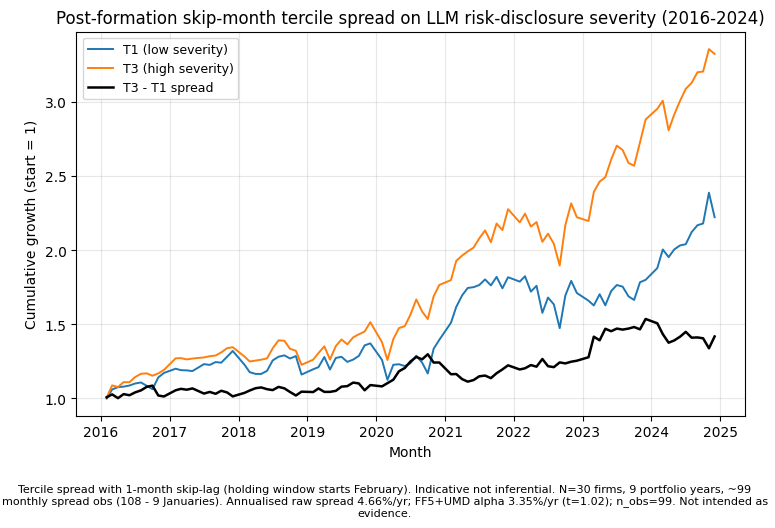

In [9]:
plot_postformation_spread(panel, summary, out_path=FIGURE_OUT)
png_path = FIGURE_OUT.with_suffix('.png')
plot_postformation_spread(panel, summary, out_path=png_path)
display(Image(filename=str(png_path)))


## Caveats

- **Power**: 30 firms split across 3 terciles leaves 10 firms per leg, statistically thin.
- **Severity validity**: severities are LLM (or LM) judgements of disclosure language; not validated against expert ratings or external risk benchmarks.
- **Taxonomy**: the 10-theme list is hand-listed and illustrative; production use would require a data-driven taxonomy.
- **Reproducibility**: `provenance.json` + `extraction_prompt.md` + the `corpus.ndjson.gz` SHA chain enable a full audit of how every severity was produced.


## Reproduction

```
git clone <repo>
cd 07_NarrativeRisk_LLM_PostFormation
make data                  # fetch third-party data + regenerate seed-pinned inputs
make demo                  # this notebook -> postformation_spread_summary.csv + postformation_spread.pdf
make test-all              # quantlet test suite
```
